# Create VAE for the different words sin disntace functions

In [285]:
# Add import 
import sys
import torch 
from torch import nn
from torch import optim
from prodigyopt import Prodigy # proddigy optimizer from https://github.com/konstmish/prodigy?tab=readme-ov-file
import pytorch_lightning as pl

import tqdm
import numpy as np
import matplotlib.pyplot as plt
# allow reload of python modules
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
from dataset.RobotPathDataset.normalizer import MinMaxFeatureNormalizer

from model.models import EMA
import copy
import time

# remove all warnings
import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [286]:
normalizer = MinMaxFeatureNormalizer()
encoder_normalizer = MinMaxFeatureNormalizer()
representation_dim = 256
CONFIG = {
    # Model configuration
    'representation_dim': representation_dim,
    'dim_mults':(1,4,8), # Dimension multipliers for hidden layers of the model # (1, 4, 8)
    
    # Encoder configuration
    'embeder_num_of_hidden_layers' : 1,
    'vae_kwargs': {
        'in_channels':1,
        'latent_dim': representation_dim,
        'hidden_dims': None,
    },
    
    # Hyperparameters for training
    'batch_size': 8,
    'num_epochs': 20,
    'ema': EMA(beta=0.99), # Exponential moving average for the model weights
        ## Optimizer configuration
        'optimizer': Prodigy,
        'optimizer_kwargs': {
            'lr': 1., # ! ONLY FOR PRODIGY OPTIMIZER
            'weight_decay': 0.01, 
            'safeguard_warmup':True,
            'use_bias_correction':True,
            'betas': (0.9, 0.99),
            },
        # Scheduler configuration
        'scheduler': torch.optim.lr_scheduler.CosineAnnealingLR,
        'scheduler_kwargs': {
            # 'gamma': 0.999,
            'T_max': 10, # Total number of iterations
        },
    
    # Hyperparameters for diffusion process
    'noise_steps': 256,
    'normalize': True,
    'normalizer':normalizer,
    'encoder_normalizer':encoder_normalizer,
    'cfg_scale': 3,


    # Dataset specific configuration
    'n_paths_per_world': 10,
    'n_worlds': 10,
    'n_waypoints': 64, # due to the archtechture has to be a number that is a power of 2 
}

# DataLoader

In [287]:
from dataset import RobotPathDataset
file = 'D:\Desktop\ADLR\RobotPathData\data\SingleSphere02_all.db'
# file = 'D:\Desktop\ADLR\RobotPathData\data\SingleSphere02_one-world.db'
dataset = RobotPathDataset(file, n_paths_per_world=CONFIG['n_paths_per_world'], n_worlds=CONFIG['n_worlds'],  n_waypoints=CONFIG['n_waypoints'],   normalizer=CONFIG['normalizer'])
print(f' sample shape {dataset[0]["path"].shape} with {len(dataset)} samples')

world_indx: 10, world_distance_field_images: torch.Size([64, 64])
world_indx: 21, world_distance_field_images: torch.Size([64, 64])
world_indx: 23, world_distance_field_images: torch.Size([64, 64])
world_indx: 40, world_distance_field_images: torch.Size([64, 64])
world_indx: 42, world_distance_field_images: torch.Size([64, 64])
world_indx: 45, world_distance_field_images: torch.Size([64, 64])
world_indx: 49, world_distance_field_images: torch.Size([64, 64])
world_indx: 50, world_distance_field_images: torch.Size([64, 64])
world_indx: 52, world_distance_field_images: torch.Size([64, 64])
world_indx: 57, world_distance_field_images: torch.Size([64, 64])
data shape: torch.Size([100, 64, 2]), min_values: tensor([0, 0], device='cuda:0'), max_values: tensor([10, 10], device='cuda:0'), n_worlds:10, samples: 100
 sample shape torch.Size([64, 2]) with 100 samples


In [288]:
from dataset.RobotPathDataset.obstacle_distance import img2dist_img

In [289]:
class WorldsDataset(torch.utils.data.Dataset):
    def __init__(self, dataset:RobotPathDataset, sign_dist_field=False):
        worlds_dataset = dataset.all_world_images
        self.data = []
        
        self.voxel_size = 10 / 64     # in m

        if sign_dist_field:
            for i in range(len(worlds_dataset)):
                dist_field= torch.tensor(img2dist_img(img=worlds_dataset[i], voxel_size=self.voxel_size, add_boundary=True), dtype=torch.float32)
                self.data.append(dist_field)
                
        self.data = torch.stack(self.data)
        self.data = self.data.unsqueeze(1)
    def __getitem__(self, idx):
        return self.data[idx]
    
    def __len__(self):
        return len(self.data)

In [290]:
world_dataset = WorldsDataset(dataset, sign_dist_field=True)
print(f' sample shape {world_dataset[0].shape} with {len(world_dataset)} samples')

 sample shape torch.Size([1, 64, 64]) with 10000 samples


In [291]:
sample = world_dataset[9]
sample

tensor([[[0.1562, 0.1562, 0.1562,  ..., 0.1562, 0.1562, 0.1562],
         [0.1562, 0.3125, 0.3125,  ..., 0.3125, 0.3125, 0.1562],
         [0.1562, 0.3125, 0.4688,  ..., 0.4688, 0.3125, 0.1562],
         ...,
         [0.1562, 0.3125, 0.4688,  ..., 0.1562, 0.3125, 0.1562],
         [0.1562, 0.3125, 0.3125,  ..., 0.1562, 0.3125, 0.1562],
         [0.1562, 0.1562, 0.1562,  ..., 0.1562, 0.1562, 0.1562]]])

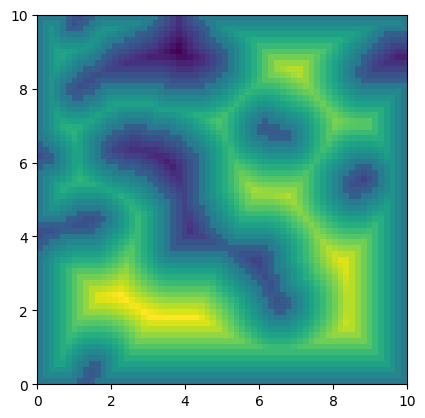

In [292]:

plt.imshow(sample.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')

### Dataloader

In [293]:
dataloader = torch.utils.data.DataLoader(world_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
sample_batch = next(iter(dataloader))

# Model

In [294]:
from model.vae import VanillaVAE, BaseVAE

In [295]:
normalizer = MinMaxFeatureNormalizer()
model = VanillaVAE(**CONFIG['vae_kwargs'], normalizer=normalizer)

In [296]:
normalized_sample_batch = normalizer.normalize(sample_batch)

In [297]:
mu, log_var = model.encode(sample_batch)
z = model.reparameterize(mu, log_var)
reconstructed = model.decode(z)
assert reconstructed.shape == sample_batch.shape , f'{reconstructed.shape} != {sample_batch.shape}'

In [298]:
results = model.forward(sample_batch)
results
model.loss_function(*results, M_N=1)

{'loss': tensor(38.1400, grad_fn=<AddBackward0>),
 'Reconstruction_Loss': tensor(1.8243),
 'KLD': tensor(-36.3158)}

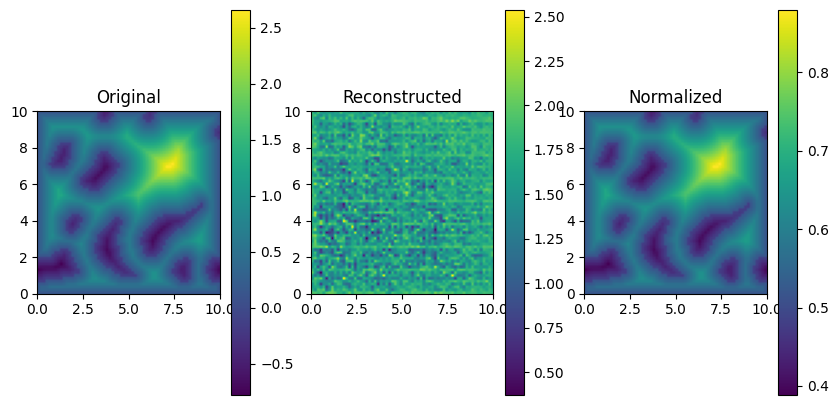

In [299]:
# visualize const vs reconstructed
fig, ax = plt.subplots(1,3, figsize=(10,5))
pos = ax[0].imshow(sample_batch[0].squeeze().T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
ax[0].set_title('Original')
fig.colorbar(pos, ax=ax[0])
pos = ax[1].imshow(reconstructed[0].squeeze().T.cpu().detach().numpy(), origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
ax[1].set_title('Reconstructed')
fig.colorbar(pos, ax=ax[1])
pos = ax[2].imshow(normalized_sample_batch[0].squeeze().T.cpu().detach().numpy(), origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
ax[2].set_title('Normalized')
fig.colorbar(pos, ax=ax[2])

In [316]:
from torch import Tensor


class VAEXperiment(pl.LightningModule):

    def __init__(self,
                 vae_model: BaseVAE,
                 params: dict) -> None:
        super(VAEXperiment, self).__init__()

        self.model = vae_model
        self.params = params
        self.curr_device = None


    def training_step(self, batch, batch_idx):
        real_img = batch
        self.curr_device = real_img.device

        results = self.forward(real_img)
        train_loss = self.model.loss_function(*results,
                                              M_N = 0.0032, #al_img.shape[0]/ self.num_train_imgs,
        )

        self.log_dict({key: val.item() for key, val in train_loss.items()}, sync_dist=True)

        return train_loss['loss']
    def validation_step(self, batch, batch_idx, optimizer_idx = 0):
        real_img, labels = batch
        self.curr_device = real_img.device

        results = self.forward(real_img, labels = labels)
        val_loss = self.model.loss_function(*results,
                                            M_N = 1.0, #real_img.shape[0]/ self.num_val_imgs,
                                            optimizer_idx = optimizer_idx,
                                            batch_idx = batch_idx)

        self.log_dict({f"val_{key}": val.item() for key, val in val_loss.items()}, sync_dist=True)
        
    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=1e-3)
        # optimizer =  Prodigy(self.parameters(), lr=1.)
        return optimizer
    
    def forward(self, input: Tensor, **kwargs) -> Tensor:
        return self.model(input, **kwargs)
    
    def on_train_epoch_end(self):
        NUM_SAMPLES = 8
        # Get some batch of validation data
        with torch.no_grad():
            all_preds = next(iter(self.trainer.train_dataloader))
            data = all_preds[0:NUM_SAMPLES]
            data = data.to(self.curr_device)

        # Forward pass
        results = self.forward(data)
        recon_results = results[0]
        # Visualize results
        self.visualize_results(data, recon_results)
        if self.current_epoch % 10 == 0:
            self.visualize_embeddings()
    
    def visualize_embeddings(self):
        tensorboard = self.logger.experiment
        # get 4 batches of data
        all_preds = next(iter(self.trainer.train_dataloader))
        for i in range(4):
            all_preds = torch.cat((all_preds, next(iter(self.trainer.train_dataloader))), dim=0)    
        data = all_preds.to(self.curr_device)
        # get embeddings
        mu, _ = self.model.encode(data)
        # log embeddings
        tensorboard.add_embedding(mu,
                                  global_step=self.current_epoch,
                                  tag='latent_space',
                                  label_img=data) 
        
        
    def visualize_results(self, real_img, results):
        tensorboard = self.logger.experiment
        n = min(real_img.size(0), 8)
        real_imgs = real_img[:n]
        recon_imgs = results[:n]
        fig, ax = plt.subplots(n,2, figsize=(10,5))
        for i in range(n):
            ax[i,0].imshow(real_imgs[i].squeeze().T.cpu().detach().numpy(), origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
            ax[i,0].set_title('Original')
            ax[i,1].imshow(recon_imgs[i].squeeze().T.cpu().detach().numpy(), origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
            ax[i,1].set_title('Reconstructed')
        tensorboard.add_figure('reconstructions', fig, global_step=self.current_epoch)
        



In [317]:
autoencoder = VAEXperiment(model, CONFIG['vae_kwargs'])

In [318]:
# DEBUG lightning before running full training
trainer = pl.Trainer(limit_train_batches=64, max_epochs=5)
trainer.fit(model=autoencoder, train_dataloaders=dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type       | Params
-------------------------------------
0 | model | VanillaVAE | 4.7 M 
-------------------------------------
4.7 M     Trainable params
0         Non-trainable params
4.7 M     Total params
18.892    Total estimated model params size (MB)


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


In [319]:
trainer = pl.Trainer()
trainer.fit(model=autoencoder, train_dataloaders=dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type       | Params
-------------------------------------
0 | model | VanillaVAE | 4.7 M 
-------------------------------------
4.7 M     Trainable params
0         Non-trainable params
4.7 M     Total params
18.892    Total estimated model params size (MB)


Training: |          | 0/? [00:00<?, ?it/s]

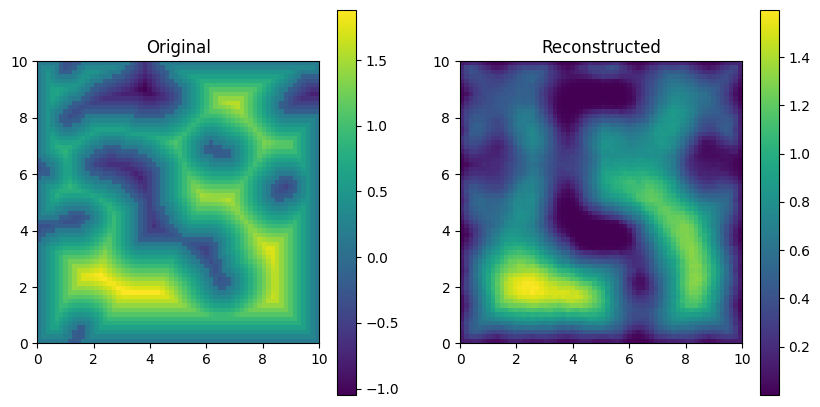

In [304]:
model = autoencoder.model
model.eval()
sample = world_dataset[9]
sample = sample.unsqueeze(0)
sample = sample.to(autoencoder.curr_device)
mu, log_var = model.encode(sample)
z = model.reparameterize(mu, log_var)
reconstructed = model.decode(z)
assert reconstructed.shape == sample.shape , f'{reconstructed.shape} != {sample.shape}'
# visualize const vs reconstructed
fig, ax = plt.subplots(1,2, figsize=(10,5))
pos = ax[0].imshow(sample[0].squeeze().T.cpu().detach(), origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
ax[0].set_title('Original')
fig.colorbar(pos, ax=ax[0])
pos = ax[1].imshow(reconstructed[0].squeeze().T.cpu().detach().numpy(), origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
ax[1].set_title('Reconstructed')
fig.colorbar(pos, ax=ax[1])
